In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

Matplotlib is building the font cache; this may take a moment.


In [2]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd().parent
DATA_PATH = BASE_DIR / "data" / "processed" / "all_nav_history.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (20026, 3)

Columns:
['scheme', 'date', 'nav']


,scheme,date,nav
0,HDFC_Top100_Direct,2013-11-18,13.0894
1,HDFC_Top100_Direct,2013-11-19,13.1068
2,HDFC_Top100_Direct,2013-11-20,12.9549
3,HDFC_Top100_Direct,2013-11-21,12.7957
4,HDFC_Top100_Direct,2013-11-22,12.7775


In [3]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (20026, 3)

Data Types:
scheme        str
date          str
nav       float64
dtype: object

Missing Values:
scheme    0
date      0
nav       0
dtype: int64

Duplicate Rows: 0


In [4]:
# Make sure date is in datetime format
df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")

# Convert NAV to numeric
df["nav"] = pd.to_numeric(df["nav"], errors="coerce")

print("Date range:")
print(df["date"].min(), "to", df["date"].max())

print("\nSchemes available:")
print(df["scheme"].unique())

print("\nNumber of records per scheme:")
print(df.groupby("scheme").size())


Date range:
2012-12-31 00:00:00 to 2026-07-24 00:00:00

Schemes available:
<StringArray>
['HDFC_Top100_Direct',       'SBI_Bluechip',     'ICICI_Bluechip',
   'Nippon_Large_Cap',      'Axis_Bluechip',     'Kotak_Bluechip']
Length: 6, dtype: str

Number of records per scheme:
scheme
Axis_Bluechip         3603
HDFC_Top100_Direct    3129
ICICI_Bluechip        3345
Kotak_Bluechip        3339
Nippon_Large_Cap      3336
SBI_Bluechip          3274
dtype: int64


C:\Users\DELL\AppData\Local\Temp\ipykernel_8776\2209776492.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["date"] = pd.to_datetime(df["date"], dayfirst=True, errors="coerce")


In [5]:
scheme_summary = df.groupby("scheme")["nav"].agg(
    ["count", "min", "max", "mean", "std"]
).round(2)

scheme_summary

,count,min,max,mean,std
scheme,,,,,
Axis_Bluechip,3603,23.99,6242.17,3420.69,1989.59
HDFC_Top100_Direct,3129,12.78,214.68,91.31,61.24
ICICI_Bluechip,3345,0.00,113.68,57.27,29.36
Kotak_Bluechip,3339,30.56,281.11,103.59,76.97
Nippon_Large_Cap,3336,12.22,106.13,46.70,28.02
SBI_Bluechip,3274,102.23,161.38,125.60,19.26


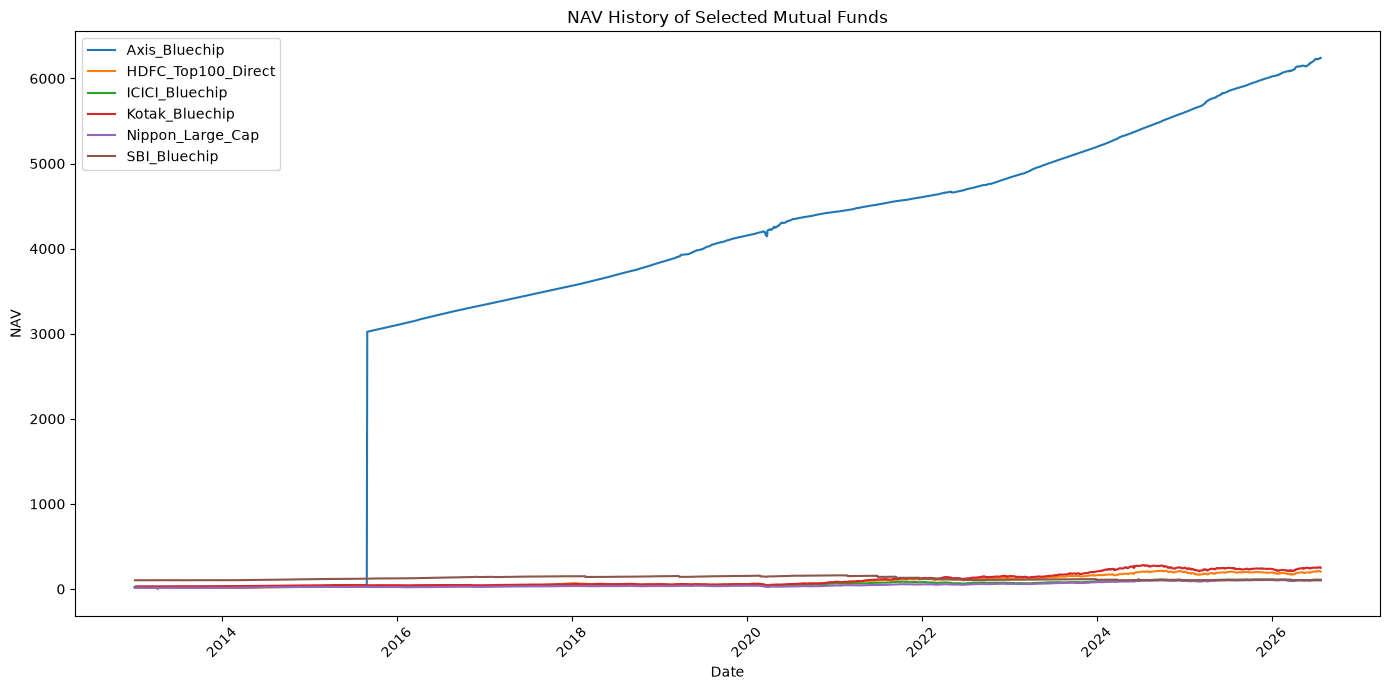

In [6]:
plt.figure(figsize=(14, 7))

for scheme, group in df.groupby("scheme"):
    group = group.sort_values("date")
    plt.plot(group["date"], group["nav"], label=scheme)

plt.title("NAV History of Selected Mutual Funds")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
df = df.sort_values(["scheme", "date"])

df["daily_return"] = (
    df.groupby("scheme")["nav"]
      .pct_change()
)

df[["scheme", "date", "nav", "daily_return"]].head(10)

,scheme,date,nav,daily_return
13084,Axis_Bluechip,2012-12-31,23.9920,NaN
13085,Axis_Bluechip,2013-01-01,23.9979,0.000246
13086,Axis_Bluechip,2013-01-02,24.0036,0.000238
13087,Axis_Bluechip,2013-01-03,24.0092,0.000233
13088,Axis_Bluechip,2013-01-04,24.0147,0.000229
13089,Axis_Bluechip,2013-01-06,24.0258,0.000462
13090,Axis_Bluechip,2013-01-07,24.0314,0.000233
13091,Axis_Bluechip,2013-01-08,24.0369,0.000229
13092,Axis_Bluechip,2013-01-09,24.0424,0.000229
13093,Axis_Bluechip,2013-01-10,24.0479,0.000229


In [8]:
df = df.sort_values(["scheme", "date"])

df["daily_return"] = (
    df.groupby("scheme")["nav"]
      .pct_change()
)

df[["scheme", "date", "nav", "daily_return"]].head(10)

,scheme,date,nav,daily_return
13084,Axis_Bluechip,2012-12-31,23.9920,NaN
13085,Axis_Bluechip,2013-01-01,23.9979,0.000246
13086,Axis_Bluechip,2013-01-02,24.0036,0.000238
13087,Axis_Bluechip,2013-01-03,24.0092,0.000233
13088,Axis_Bluechip,2013-01-04,24.0147,0.000229
13089,Axis_Bluechip,2013-01-06,24.0258,0.000462
13090,Axis_Bluechip,2013-01-07,24.0314,0.000233
13091,Axis_Bluechip,2013-01-08,24.0369,0.000229
13092,Axis_Bluechip,2013-01-09,24.0424,0.000229
13093,Axis_Bluechip,2013-01-10,24.0479,0.000229


In [9]:
return_summary = df.groupby("scheme")["daily_return"].agg(
    ["mean", "std", "min", "max"]
).round(6)

return_summary

,mean,std,min,max
scheme,,,,
Axis_Bluechip,0.027762,1.650243,-0.005415,99.042353
HDFC_Top100_Direct,0.000926,0.009560,-0.096964,0.046026
ICICI_Bluechip,inf,NaN,-1.000000,inf
Kotak_Bluechip,0.000676,0.009698,-0.100119,0.070446
Nippon_Large_Cap,0.000629,0.010490,-0.129512,0.070415
SBI_Bluechip,0.000026,0.005460,-0.113092,0.128260


In [10]:
volatility = (
    df.groupby("scheme")["daily_return"]
      .std()
      .mul(np.sqrt(252))
      .mul(100)
      .sort_values(ascending=False)
)

print("Annualized Volatility (%):")
print(volatility.round(2))

Annualized Volatility (%):
scheme
Axis_Bluechip         2619.68
Nippon_Large_Cap        16.65
Kotak_Bluechip          15.39
HDFC_Top100_Direct      15.18
SBI_Bluechip             8.67
ICICI_Bluechip            NaN
Name: daily_return, dtype: float64


In [11]:
returns_pivot = df.pivot(
    index="date",
    columns="scheme",
    values="daily_return"
)

correlation = returns_pivot.corr()

correlation.round(3)

scheme,Axis_Bluechip,HDFC_Top100_Direct,ICICI_Bluechip,Kotak_Bluechip,Nippon_Large_Cap,SBI_Bluechip
scheme,,,,,,
Axis_Bluechip,1.000,0.111,0.039,0.080,0.078,0.130
HDFC_Top100_Direct,0.111,1.000,0.763,0.737,0.767,0.022
ICICI_Bluechip,0.039,0.763,1.000,0.738,0.896,0.035
Kotak_Bluechip,0.080,0.737,0.738,1.000,0.769,0.021
Nippon_Large_Cap,0.078,0.767,0.896,0.769,1.000,0.028
SBI_Bluechip,0.130,0.022,0.035,0.021,0.028,1.000


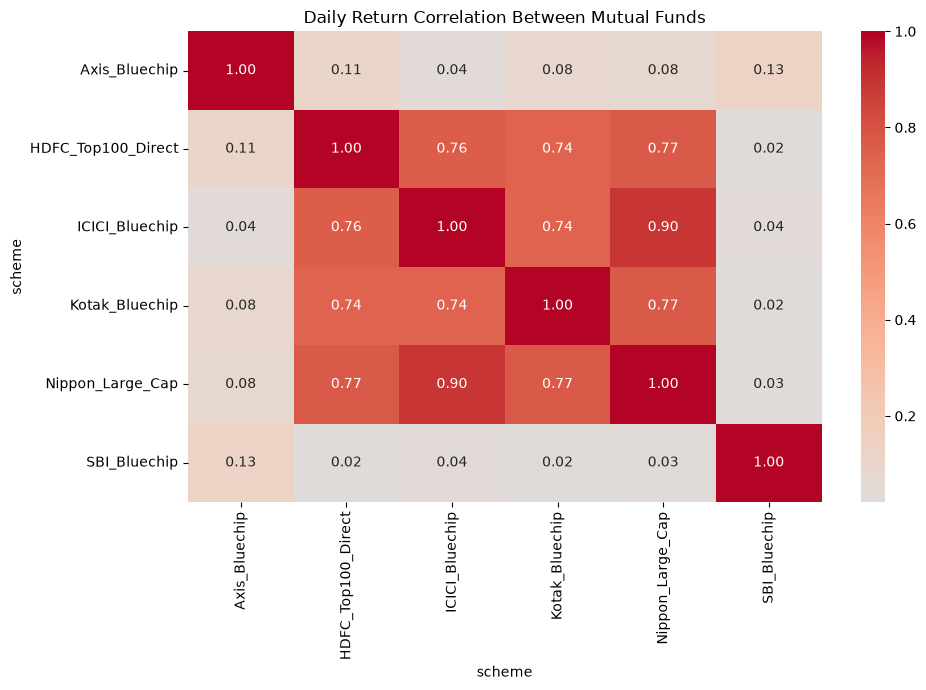

In [12]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Daily Return Correlation Between Mutual Funds")
plt.tight_layout()
plt.show()

e:\Mutual Fund Blue\venv\Lib\site-packages\numpy\_core\fromnumeric.py:54: RuntimeWarning: invalid value encountered in accumulate
  return bound(*args, **kwds)


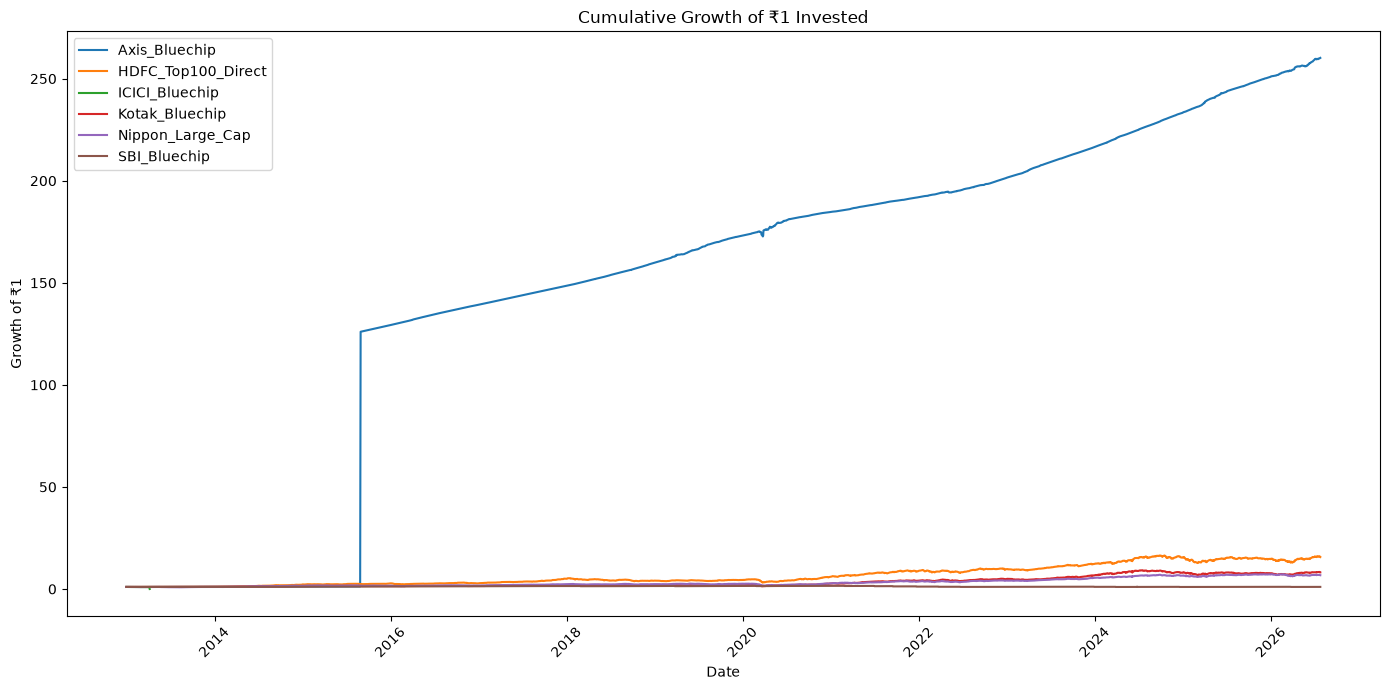

In [13]:
cumulative_returns = (
    returns_pivot
    .fillna(0)
    .add(1)
    .cumprod()
)

plt.figure(figsize=(14, 7))

for scheme in cumulative_returns.columns:
    plt.plot(
        cumulative_returns.index,
        cumulative_returns[scheme],
        label=scheme
    )

plt.title("Cumulative Growth of ₹1 Invested")
plt.xlabel("Date")
plt.ylabel("Growth of ₹1")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
best_returns = df.loc[
    df.groupby("scheme")["daily_return"].idxmax(),
    ["scheme", "date", "daily_return"]
]

worst_returns = df.loc[
    df.groupby("scheme")["daily_return"].idxmin(),
    ["scheme", "date", "daily_return"]
]

print("Best Daily Return:")
display(best_returns)

print("\nWorst Daily Return:")
display(worst_returns)

Best Daily Return:


,scheme,date,daily_return
13889,Axis_Bluechip,2015-08-30,99.042353
1676,HDFC_Top100_Direct,2020-09-14,0.046026
6470,ICICI_Bluechip,2013-04-08,inf
18472,Kotak_Bluechip,2020-04-07,0.070446
11530,Nippon_Large_Cap,2020-04-07,0.070415
5895,SBI_Bluechip,2024-06-24,0.128260



Worst Daily Return:


,scheme,date,daily_return
15150,Axis_Bluechip,2020-03-19,-0.005415
1557,HDFC_Top100_Direct,2020-03-23,-0.096964
6469,ICICI_Bluechip,2013-04-07,-1.000000
18463,Kotak_Bluechip,2020-03-23,-0.100119
11521,Nippon_Large_Cap,2020-03-23,-0.129512
5896,SBI_Bluechip,2024-06-25,-0.113092


In [15]:
best_returns = df.loc[
    df.groupby("scheme")["daily_return"].idxmax(),
    ["scheme", "date", "daily_return"]
]

worst_returns = df.loc[
    df.groupby("scheme")["daily_return"].idxmin(),
    ["scheme", "date", "daily_return"]
]

print("Best Daily Return:")
display(best_returns)

print("\nWorst Daily Return:")
display(worst_returns)

Best Daily Return:


,scheme,date,daily_return
13889,Axis_Bluechip,2015-08-30,99.042353
1676,HDFC_Top100_Direct,2020-09-14,0.046026
6470,ICICI_Bluechip,2013-04-08,inf
18472,Kotak_Bluechip,2020-04-07,0.070446
11530,Nippon_Large_Cap,2020-04-07,0.070415
5895,SBI_Bluechip,2024-06-24,0.128260



Worst Daily Return:


,scheme,date,daily_return
15150,Axis_Bluechip,2020-03-19,-0.005415
1557,HDFC_Top100_Direct,2020-03-23,-0.096964
6469,ICICI_Bluechip,2013-04-07,-1.000000
18463,Kotak_Bluechip,2020-03-23,-0.100119
11521,Nippon_Large_Cap,2020-03-23,-0.129512
5896,SBI_Bluechip,2024-06-25,-0.113092


In [ ]:
## Key EDA Insights

1. NAV trends were examined for all selected mutual fund schemes.
2. Daily returns were calculated separately for each scheme.
3. Annualized volatility was calculated using 252 trading days.
4. The correlation analysis shows the degree to which the selected funds' daily returns move together.
5. The cumulative growth chart provides a comparative view of NAV performance over the available period.
6. Best and worst daily-return observations were identified for each scheme.
7. These findings will be used as inputs for the performance analysis in D4.